In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/watchman/rtsd-dataset/train_anno_reduced.json
/kaggle/input/datasets/watchman/rtsd-dataset/train_anno.json
/kaggle/input/datasets/watchman/rtsd-dataset/labels.txt
/kaggle/input/datasets/watchman/rtsd-dataset/label_map.json
/kaggle/input/datasets/watchman/rtsd-dataset/val_anno.json


KeyboardInterrupt: 

In [2]:
import kagglehub

path = kagglehub.dataset_download("watchman/rtsd-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/watchman/rtsd-dataset


In [3]:
import json
from pathlib import Path

root = Path('/kaggle/input/datasets/watchman/rtsd-dataset')

with open(root / 'train_anno.json') as f:
    data = json.load(f)

print('Ключи в train_anno.json:', list(data.keys()))

Ключи в train_anno.json: ['images', 'annotations', 'categories']


In [ ]:
if 'annotations' in data:
    print('Всего аннотаций:', len(data['annotations']))
    print('Пример аннотации:')
    print(data['annotations'][0])
else:
    if 'root' in data:
        print('Ключи внутри root:', list(data['root'].keys()))

In [ ]:
cats = data['categories']
print(f'Всего категорий: {len(cats)}')
print('Первые 10:')
for c in cats[:10]:
    print(f"  id={c['id']}  name={c['name']}")

In [ ]:
from collections import Counter

id_to_name = {c['id']: c['name'] for c in data['categories']}
counts = Counter(a['category_id'] for a in data['annotations'])

print('Топ-20 классов:')
for cat_id, cnt in counts.most_common(20):
    name = id_to_name.get(cat_id, '?')
    print(f'{cnt:6d} объектов  |  id={cat_id:3d}  |  {name}')

In [ ]:
images = data['images']
print(f'Всего изображений в train: {len(images)}')
print('Примеры имён:')
for img in images[:8]:
    print(img['file_name'])

In [ ]:
import numpy as np

areas = [a['area'] for a in data['annotations']]
widths = [a['bbox'][2] for a in data['annotations']]
heights = [a['bbox'][3] for a in data['annotations']]

print(f'Площадь бокса:  min={min(areas)}  median={np.median(areas):.0f}  max={max(areas)}')
print(f'Ширина бокса:   min={min(widths)}  median={np.median(widths):.0f}  max={max(widths)}')
print(f'Высота бокса:   min={min(heights)}  median={np.median(heights):.0f}  max={max(heights)}')

In [ ]:
import re
from collections import defaultdict

images = data['images']

sessions = defaultdict(list)
for img in images:
    fname = Path(img['file_name']).stem
    parts = fname.split('_')
    session_key = '_'.join(parts[:-1])
    sessions[session_key].append(img['id'])

print(f'Всего сессий: {len(sessions)}')
print(f'Первые 5 сессий:')
for key, ids in list(sessions.items())[:5]:
    print(f'{key}: {len(ids)} кадров')

In [ ]:
chosen = {
    4:  '3_24',   # ограничение скорости
    13: '2_4',    # уступи дорогу
    26: '3_27',   # остановка запрещена
    2:  '1_23',   # опасность
    23: '4_1_1',  # движение прямо
    6:  '5_20',   # пешеходный переход
}

import numpy as np

print('Размеры боксов по классам:\n')
print(f'{"Класс":<12} {"Всего":>7} {">=32px":>8} {">=48px":>8} {">=64px":>8}  медиана')

for cat_id, name in chosen.items():
    annos_cls = [a for a in data['annotations'] if a['category_id'] == cat_id]
    sizes = [(a['bbox'][2], a['bbox'][3]) for a in annos_cls]
    
    total = len(sizes)
    cnt_32 = sum(1 for w,h in sizes if w >= 32 and h >= 32)
    cnt_48 = sum(1 for w,h in sizes if w >= 48 and h >= 48)
    cnt_64 = sum(1 for w,h in sizes if w >= 64 and h >= 64)
    median_w = np.median([w for w,h in sizes])
    
    print(f'{name:<12} {total:>7} {cnt_32:>8} {cnt_48:>8} {cnt_64:>8}  {median_w:.0f}px')

In [ ]:
from collections import defaultdict

img_to_signs_48 = defaultdict(set)

for a in data['annotations']:
    if a['category_id'] in chosen:
        w, h = a['bbox'][2], a['bbox'][3]
        if w >= 48 and h >= 48:
            img_to_signs_48[a['image_id']].add(a['category_id'])

print(f'Картинок с хотя бы одним знаком ≥48px: {len(img_to_signs_48)}')

cnt_per_class = Counter()
for cats_set in img_to_signs_48.values():
    for c in cats_set:
        cnt_per_class[c] += 1

print('Объектов на класс при фильтре ≥48px:')
for cat_id, name in chosen.items():
    print(f'  {name:<12} {cnt_per_class[cat_id]:>6}')

In [ ]:
with open(root / 'val_anno.json') as f:
    val_data = json.load(f)

print('Изображений в val:', len(val_data['images']))
print('Аннотаций в val:', len(val_data['annotations']))

cnt_val = Counter()
for a in val_data['annotations']:
    if a['category_id'] in chosen:
        w, h = a['bbox'][2], a['bbox'][3]
        if w >= 48 and h >= 48:
            cnt_val[a['category_id']] += 1

print('Объектов на класс в val (≥48px):')
for cat_id, name in chosen.items():
    print(f'{name:<12} {cnt_val[cat_id]:>6}')

In [4]:
import json
import random
import shutil
from pathlib import Path
from collections import defaultdict

In [5]:
OUT  = Path('/kaggle/working/rtsd_yolo')

CHOSEN = {4: '3_24', 13: '2_4', 26: '3_27', 2: '1_23', 23: '4_1_1', 6: '5_20'}
MIN_SIZE = 48

with open(root / 'train_anno.json') as f:
    train_data = json.load(f)
with open(root / 'val_anno.json') as f:
    val_data = json.load(f)

In [6]:
all_images = train_data['images'] + val_data['images']
all_annos  = train_data['annotations'] + val_data['annotations']

print(f'Всего картинок в пуле: {len(all_images)}')
print(f'Всего аннотаций в пуле: {len(all_annos)}')

Всего картинок в пуле: 59188
Всего аннотаций в пуле: 104358


In [7]:
anno_by_img = defaultdict(list)

for a in all_annos:
    if a['category_id'] not in CHOSEN:
        continue
    w, h = a['bbox'][2], a['bbox'][3]
    if w < MIN_SIZE or h < MIN_SIZE:
        continue
    anno_by_img[a['image_id']].append(a)

relevant_ids = set(anno_by_img.keys())
print(f'Картинок с нужными знаками ≥{MIN_SIZE}px: {len(relevant_ids)}')

img_by_id = {img['id']: img for img in all_images}

Картинок с нужными знаками ≥48px: 4316


In [8]:
def get_session(file_name):
    stem = Path(file_name).stem
    parts = stem.split('_')
    return '_'.join(parts[:-1])

sessions = defaultdict(list)
for img_id in relevant_ids:
    img = img_by_id[img_id]
    session = get_session(img['file_name'])
    sessions[session].append(img_id)

print(f'Всего сессий: {len(sessions)}')
print(f'Среднее картинок в сессии: {len(relevant_ids)/len(sessions):.1f}')

Всего сессий: 2203
Среднее картинок в сессии: 2.0


In [9]:
selected_ids = []

for session, img_ids in sessions.items():
    chosen_id = random.choice(img_ids)
    selected_ids.append(chosen_id)

print(f'Выбрано кадров (по одному из сессии): {len(selected_ids)}')

Выбрано кадров (по одному из сессии): 2203


In [10]:
random.shuffle(selected_ids)

n = len(selected_ids)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

split_ids = {
    'train': selected_ids[:n_train],
    'val':   selected_ids[n_train : n_train + n_val],
    'test':  selected_ids[n_train + n_val:]
}

total = len(selected_ids)
for s, ids in split_ids.items():
    print(f'{s:5s}: {len(ids):5d} картинок  ({len(ids)/total*100:.1f}%)')

train:  1542 картинок  (70.0%)
val  :   330 картинок  (15.0%)
test :   331 картинок  (15.0%)


In [11]:
print('Объектов на класс по сплитам:\n')
print(f'{"Класс":<12}  {"train":>7}  {"val":>7}  {"test":>7}')

for cat_id, name in CHOSEN.items():
    counts = {}
    for s, ids in split_ids.items():
        counts[s] = sum(
            1 for img_id in ids
            for a in anno_by_img[img_id]
            if a['category_id'] == cat_id
        )
    print(f'{name:<12}  {counts["train"]:>7}  {counts["val"]:>7}  {counts["test"]:>7}')

Объектов на класс по сплитам:

Класс           train      val     test
3_24              388       70       77
2_4               320       74       72
3_27              283       66       58
1_23              334       70       68
4_1_1             164       28       46
5_20              166       39       38


In [12]:
id_to_yolo = {cat_id: i for i, cat_id in enumerate(CHOSEN.keys())}

def save_split(img_ids, split_name):
    img_out = OUT / 'images' / split_name
    lbl_out = OUT / 'labels' / split_name
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    saved = 0
    for img_id in img_ids:
        img_info = img_by_id[img_id]
        W = img_info['width']
        H = img_info['height']
        src = root / 'rtsd-frames' / img_info['file_name']

        if not src.exists():
            continue

        lines = []
        for a in anno_by_img[img_id]:
            x, y, w, h = a['bbox']
            cx = (x + w / 2) / W
            cy = (y + h / 2) / H
            wn = w / W
            hn = h / H
            lines.append(
                f'{id_to_yolo[a["category_id"]]} {cx:.6f} {cy:.6f} {wn:.6f} {hn:.6f}'
            )

        shutil.copy2(src, img_out / src.name)
        (lbl_out / (src.stem + '.txt')).write_text('\n'.join(lines))
        saved += 1

    print(f'{split_name}: сохранено {saved} картинок')

save_split(split_ids['train'], 'train')
save_split(split_ids['val'],   'val')
save_split(split_ids['test'],  'test')

train: сохранено 1542 картинок
val: сохранено 330 картинок
test: сохранено 331 картинок


In [13]:
names_str = '\n'.join(
    f'  {i}: {name}' for i, (_, name) in enumerate(CHOSEN.items())
)

yaml_text = f"""path: {OUT.resolve().as_posix()}
train: images/train
val:   images/val
test:  images/test

nc: {len(CHOSEN)}

names:
{names_str}
"""

(OUT / 'data.yaml').write_text(yaml_text)
print(yaml_text)

path: /kaggle/working/rtsd_yolo
train: images/train
val:   images/val
test:  images/test

nc: 6

names:
  0: 3_24
  1: 2_4
  2: 3_27
  3: 1_23
  4: 4_1_1
  5: 5_20



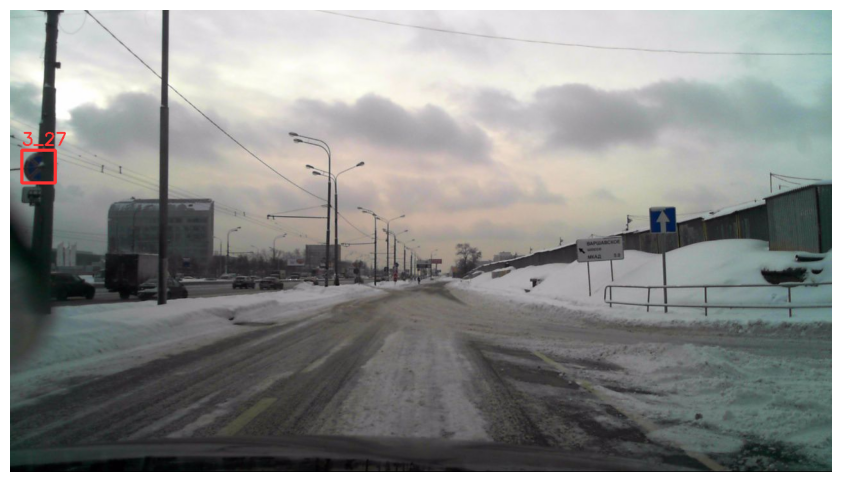

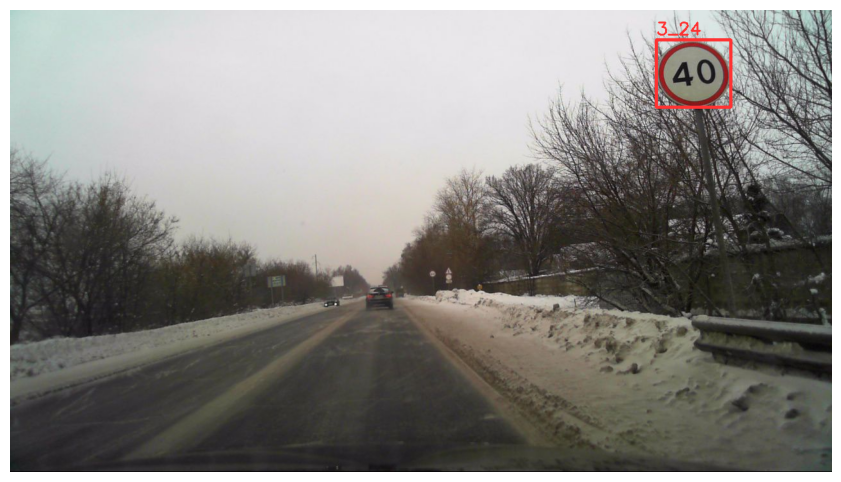

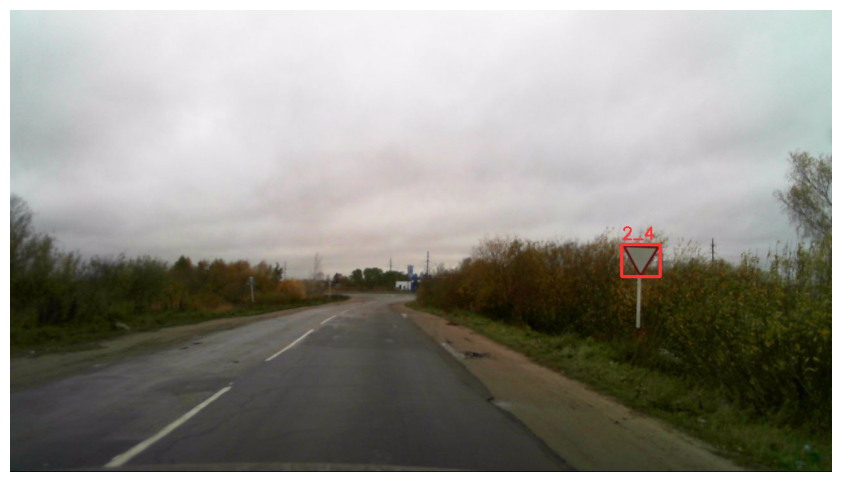

In [14]:
import cv2
import matplotlib.pyplot as plt

def check_sample(split='train', n=3):
    img_dir = OUT / 'images' / split
    lbl_dir = OUT / 'labels' / split
    imgs = list(img_dir.glob('*.jpg'))[:n]

    names = list(CHOSEN.values())

    for img_path in imgs:
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if not lbl_path.exists() or not lbl_path.read_text().strip():
            continue

        for line in lbl_path.read_text().splitlines():
            cls, cx, cy, wn, hn = map(float, line.split())
            x1 = int((cx - wn/2) * W)
            y1 = int((cy - hn/2) * H)
            x2 = int((cx + wn/2) * W)
            y2 = int((cy + hn/2) * H)
            cv2.rectangle(img, (x1,y1), (x2,y2), (255,50,50), 3)
            cv2.putText(img, names[int(cls)],
                       (x1, max(y1-8, 20)),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,50,50), 2)

        plt.figure(figsize=(14, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

check_sample('train', n=3)